<a href="https://colab.research.google.com/github/apmalani/cs-172b-project/blob/main/MNIST_RSB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BalancedCNN(nn.Module):
    def __init__(self):
        super(BalancedCNN, self).__init__()
        # Expansion Phase: Increase capacity
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # The Bottleneck: Squeeze 64 channels down to 8
        # This forces conv3 to work 8x harder, leading to weight drift
        self.conv3 = nn.Conv2d(64, 8, kernel_size=3, padding=1)

        # Recovery/Deepening Phase
        self.conv4 = nn.Conv2d(8, 32, kernel_size=3, padding=1)

        self.maxpool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()

        # Final Fully Connected Layers
        # 32 channels * 7*7 image size = 1568
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Initial Blocks
        x = self.maxpool(self.relu(self.conv1(x))) # 28->14
        x = self.relu(self.conv2(x))               # 14->14

        # The Squeeze
        x = self.relu(self.conv3(x))               # 14->14

        # The Deepening
        x = self.maxpool(self.relu(self.conv4(x))) # 14->7

        # Flatten and Classify
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [ ]:
class RSB_Loss_CNN(nn.Module):
    def __init__(self, alpha=0.01, beta=0.005):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def forward(self, outputs, targets, model):
        # 1. Classification Loss
        ce_loss = F.nll_loss(outputs, targets)

        # 2. Extract weights of Conv and Linear layers
        weights = [p for p in model.parameters() if len(p.shape) > 1]
        norms = [torch.norm(w)**2 for w in weights]

        # 3. RSB Regularization
        # Anchor the output layer
        reg = self.alpha * norms[-1]

        # Chain the balance from input to output
        for i in range(len(norms) - 1):
            reg += self.beta * (norms[i] - norms[i+1])**2

        return ce_loss + reg

In [ ]:
def get_network_balance(model):
    """Calculates the mean squared difference between adjacent weight layer norms."""
    with torch.no_grad():
        # Get weight matrices (ignoring biases for balance calculation)
        weights = [p for p in model.parameters() if len(p.shape) > 1]
        norms = [torch.sum(w**2) for w in weights]

        diffs = []
        for i in range(len(norms) - 1):
            # (Layer_k_norm - Layer_k+1_norm)^2
            diffs.append((norms[i] - norms[i+1])**2)

        return torch.mean(torch.stack(diffs)).item()

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Setup Data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_loader = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transform), batch_size=64, shuffle=True)

# Initialize Models (Identical Seeds)
torch.manual_seed(42)
rsb_model = BalancedCNN().to('cuda')
u_model = BalancedCNN().to('cuda')
u_model.load_state_dict(rsb_model.state_dict()) # Mirror weights

# Optimizers (You can use adam or SGD both work)
# rsb_opt = torch.optim.Adam(rsb_model.parameters(), lr=0.001)
# u_opt = torch.optim.Adam(u_model.parameters(), lr=0.001)
rsb_opt = torch.optim.SGD(rsb_model.parameters(), lr=0.001)
u_opt = torch.optim.SGD(u_model.parameters(), lr=0.001)

# Criteria
rsb_crit = RSB_Loss_CNN(alpha=0.0001, beta=0.01)
u_crit = nn.NLLLoss() # Standard baseline

# Training Loop
history = []
def get_accuracy(outputs, targets):
    pred = outputs.argmax(dim=1, keepdim=True)
    correct = pred.eq(targets.view_as(pred)).sum().item()
    return correct / targets.size(0)

# Training Loop
for epoch in range(1, 4):
    rsb_model.train(); u_model.train()

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to('cuda'), target.to('cuda')

        # --- RSB Model Step ---
        rsb_opt.zero_grad()
        output_b = rsb_model(data)
        loss_b = rsb_crit(output_b, target, rsb_model)
        loss_b.backward()
        rsb_opt.step()

        # --- Unbalanced Model Step ---
        u_opt.zero_grad()
        output_u = u_model(data)
        loss_u = u_crit(output_u, target)
        loss_u.backward()
        u_opt.step()

        if batch_idx % 100 == 0:
            # 1. Calculate Accuracies
            acc_b = get_accuracy(output_b, target)
            acc_u = get_accuracy(output_u, target)

            # 2. Track the Balance
            b_val = get_network_balance(rsb_model)
            u_val = get_network_balance(u_model)

            print(f"Epoch {epoch} [{batch_idx*len(data):5d}/{len(train_loader.dataset)}]")
            print(f"  > RSB:   Loss: {loss_b.item():.4f} | Acc: {acc_b:6.2%} | Balance: {b_val:.6f}")
            print(f"  > UNREG: Loss: {loss_u.item():.4f} | Acc: {acc_u:6.2%} | Balance: {u_val:.6f}")
            print("-" * 65)

            # Append to history for the vertical column plots later
            history.append({
                'epoch': epoch + batch_idx/len(train_loader),
                'b_acc': acc_b, 'u_acc': acc_u,
                'b_bal': b_val, 'u_bal': u_val
            })

Epoch 1 [    0/60000]
  > RSB:   Loss: 33.4892 | Acc:  6.25% | Balance: 615.636902
  > UNREG: Loss: 2.3052 | Acc:  6.25% | Balance: 623.674072
-----------------------------------------------------------------
Epoch 1 [ 6400/60000]
  > RSB:   Loss: 13.6636 | Acc:  6.25% | Balance: 225.301743
  > UNREG: Loss: 2.3078 | Acc:  4.69% | Balance: 623.674011
-----------------------------------------------------------------
Epoch 1 [12800/60000]
  > RSB:   Loss: 8.0684 | Acc:  6.25% | Balance: 114.594215
  > UNREG: Loss: 2.3055 | Acc:  6.25% | Balance: 623.673401
-----------------------------------------------------------------
Epoch 1 [19200/60000]
  > RSB:   Loss: 5.7193 | Acc: 12.50% | Balance: 68.133568
  > UNREG: Loss: 2.2966 | Acc:  9.38% | Balance: 623.672668
-----------------------------------------------------------------
Epoch 1 [25600/60000]
  > RSB:   Loss: 4.5013 | Acc: 32.81% | Balance: 43.955410
  > UNREG: Loss: 2.2960 | Acc: 23.44% | Balance: 623.673096
--------------------------

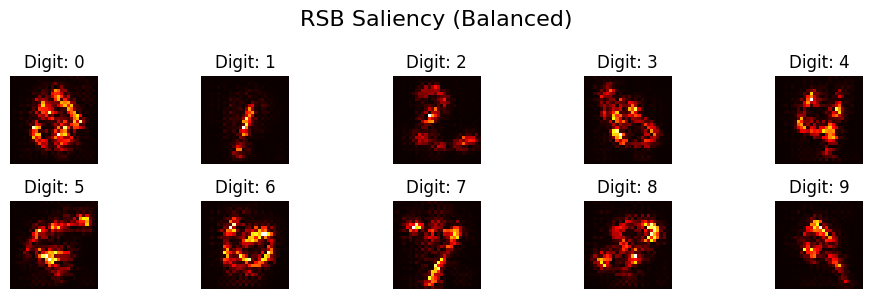

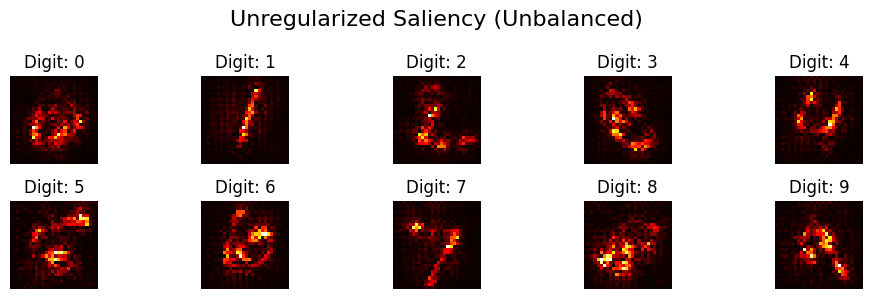

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define test_loader here, similar to train_loader
test_loader = DataLoader(datasets.MNIST('./data', train=False, download=True, transform=transform), batch_size=64, shuffle=False)

def visualize_saliency(model, title, device='cuda'):
    model.eval()
    fig, axes = plt.subplots(2, 5, figsize=(10, 3))
    fig.suptitle(title, fontsize=16)

    # Find one example of each digit from the test set
    examples = {}
    for data, target in test_loader:
        for i in range(len(target)):
            digit = target[i].item()
            if digit not in examples and len(examples) < 10:
                examples[digit] = data[i].unsqueeze(0).to(device)
        if len(examples) >= 10: break

    for i in range(10):
        img = examples[i]
        img.requires_grad_()  # We need gradients w.r.t the image

        output = model(img)
        score = output[0, i]  # The score for the actual digit
        score.backward()      # Backprop to the input

        # The saliency map is the absolute value of the gradient
        saliency, _ = torch.max(img.grad.data.abs(), dim=1)
        saliency = saliency.reshape(28, 28).cpu().numpy()

        ax = axes[i//5, i%5]
        # Overlay the saliency on the original image
        ax.imshow(saliency, cmap='hot')
        ax.set_title(f"Digit: {i}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run for both models to compare "focus"
visualize_saliency(rsb_model, title="RSB Saliency (Balanced)")
visualize_saliency(u_model, title="Unregularized Saliency (Unbalanced)")

In [ ]:
import pandas as pd
df = pd.DataFrame(history)

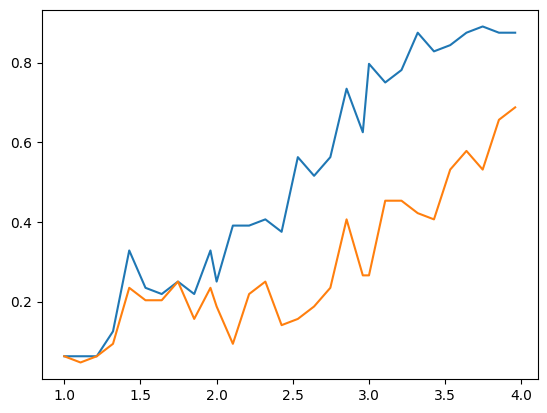

In [ ]:
plt.plot(df['epoch'],df[['b_acc','u_acc']])
plt.show()